# <span style="color: magenta;"> 1 Load Clews runner Module </span>

* <span style="color: grey;">From `clews.runner` module, load the `RunModel` Object as `clewsRun` instance </span>  

In [1]:
from bcnexus.clews.runner import RunModel
import bcnexus.utils as utils

## 1A: Define the Arguments & load _RunModel_ object

In [2]:
args = dict(
    run_scenario='Base_CNZ_noCCS',
    clustering_attributes=dict(
        hour_grouping=12,
        n_clusters=2
    )
)

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE config from : models/model_Kotzur/otoole_config_Kotzur.yaml
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 12, 'n_clusters': 2}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
ℹ️  bcnexus.attributes_parser | BC

2025-11-16 16:26:55,015 - INFO - Read LP format model from file data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS.lp


Reading time = 1.06 seconds


2025-11-16 16:26:55,016 - INFO - Reading time = 1.06 seconds


cost: 353111 rows, 349226 columns, 3242999 nonzeros


2025-11-16 16:26:55,016 - INFO - cost: 353111 rows, 349226 columns, 3242999 nonzeros


Set parameter LogToConsole to value 0


2025-11-16 16:26:55,016 - INFO - Set parameter LogToConsole to value 0
2025-11-16 16:26:55,016 - INFO - Set parameter Method to value 2
2025-11-16 16:26:55,016 - INFO - Set parameter Threads to value 32
2025-11-16 16:26:55,016 - INFO - Set parameter NumericFocus to value 0
2025-11-16 16:26:55,017 - INFO - Set parameter LogFile to value "results/clews/Model_Kotzur_Base_CNZ_noCCS/8ts/gurobi.log"
2025-11-16 16:26:55,017 - INFO - Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 20.04.6 LTS")
2025-11-16 16:26:55,017 - INFO - 
2025-11-16 16:26:55,017 - INFO - CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
2025-11-16 16:26:55,017 - INFO - Thread count: 32 physical cores, 32 logical processors, using up to 32 threads
2025-11-16 16:26:55,017 - INFO - 
2025-11-16 16:26:55,017 - INFO - Non-default parameters:
2025-11-16 16:26:55,018 - INFO - Method  2
2025-11-16 16:26:55,018 - INFO - LogToConsole  0
2025-11-16 16:26:55,018 - INFO - Threads  32


  └> --------------------------------------------------
  └─> Model run completed. Please check the log for detailed report.
 └> Optimization successful. An optimal solution is available.
└> Writing the Solution to : results/clews/Model_Kotzur_Base_CNZ_noCCS/8ts/8ts_solution_gurobi.sol
└> Extracting the shadow price of Electricity (ELCB02) from Electricity Balance Constraint
└> Preparing the summary reports for constraints, from solved model
  └> Collecting constraints reports...
  └> Summary saved to results/clews/Model_Kotzur_Base_CNZ_noCCS/8ts/constraints_summary.txt
 └> Duals extracted and saved to csv @ results/clews/Model_Kotzur_Base_CNZ_noCCS/8ts/EBa11_EnergyBalanceEachTS5_duals.csv 
└> Extracting results from Solution : results/clews/Model_Kotzur_Base_CNZ_noCCS/8ts/8ts_solution_gurobi.sol
 └> Initiating otoole interface to extract results; input csvs : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs , config file: models/model_Kotzur/otoole_config_Kotzur.y

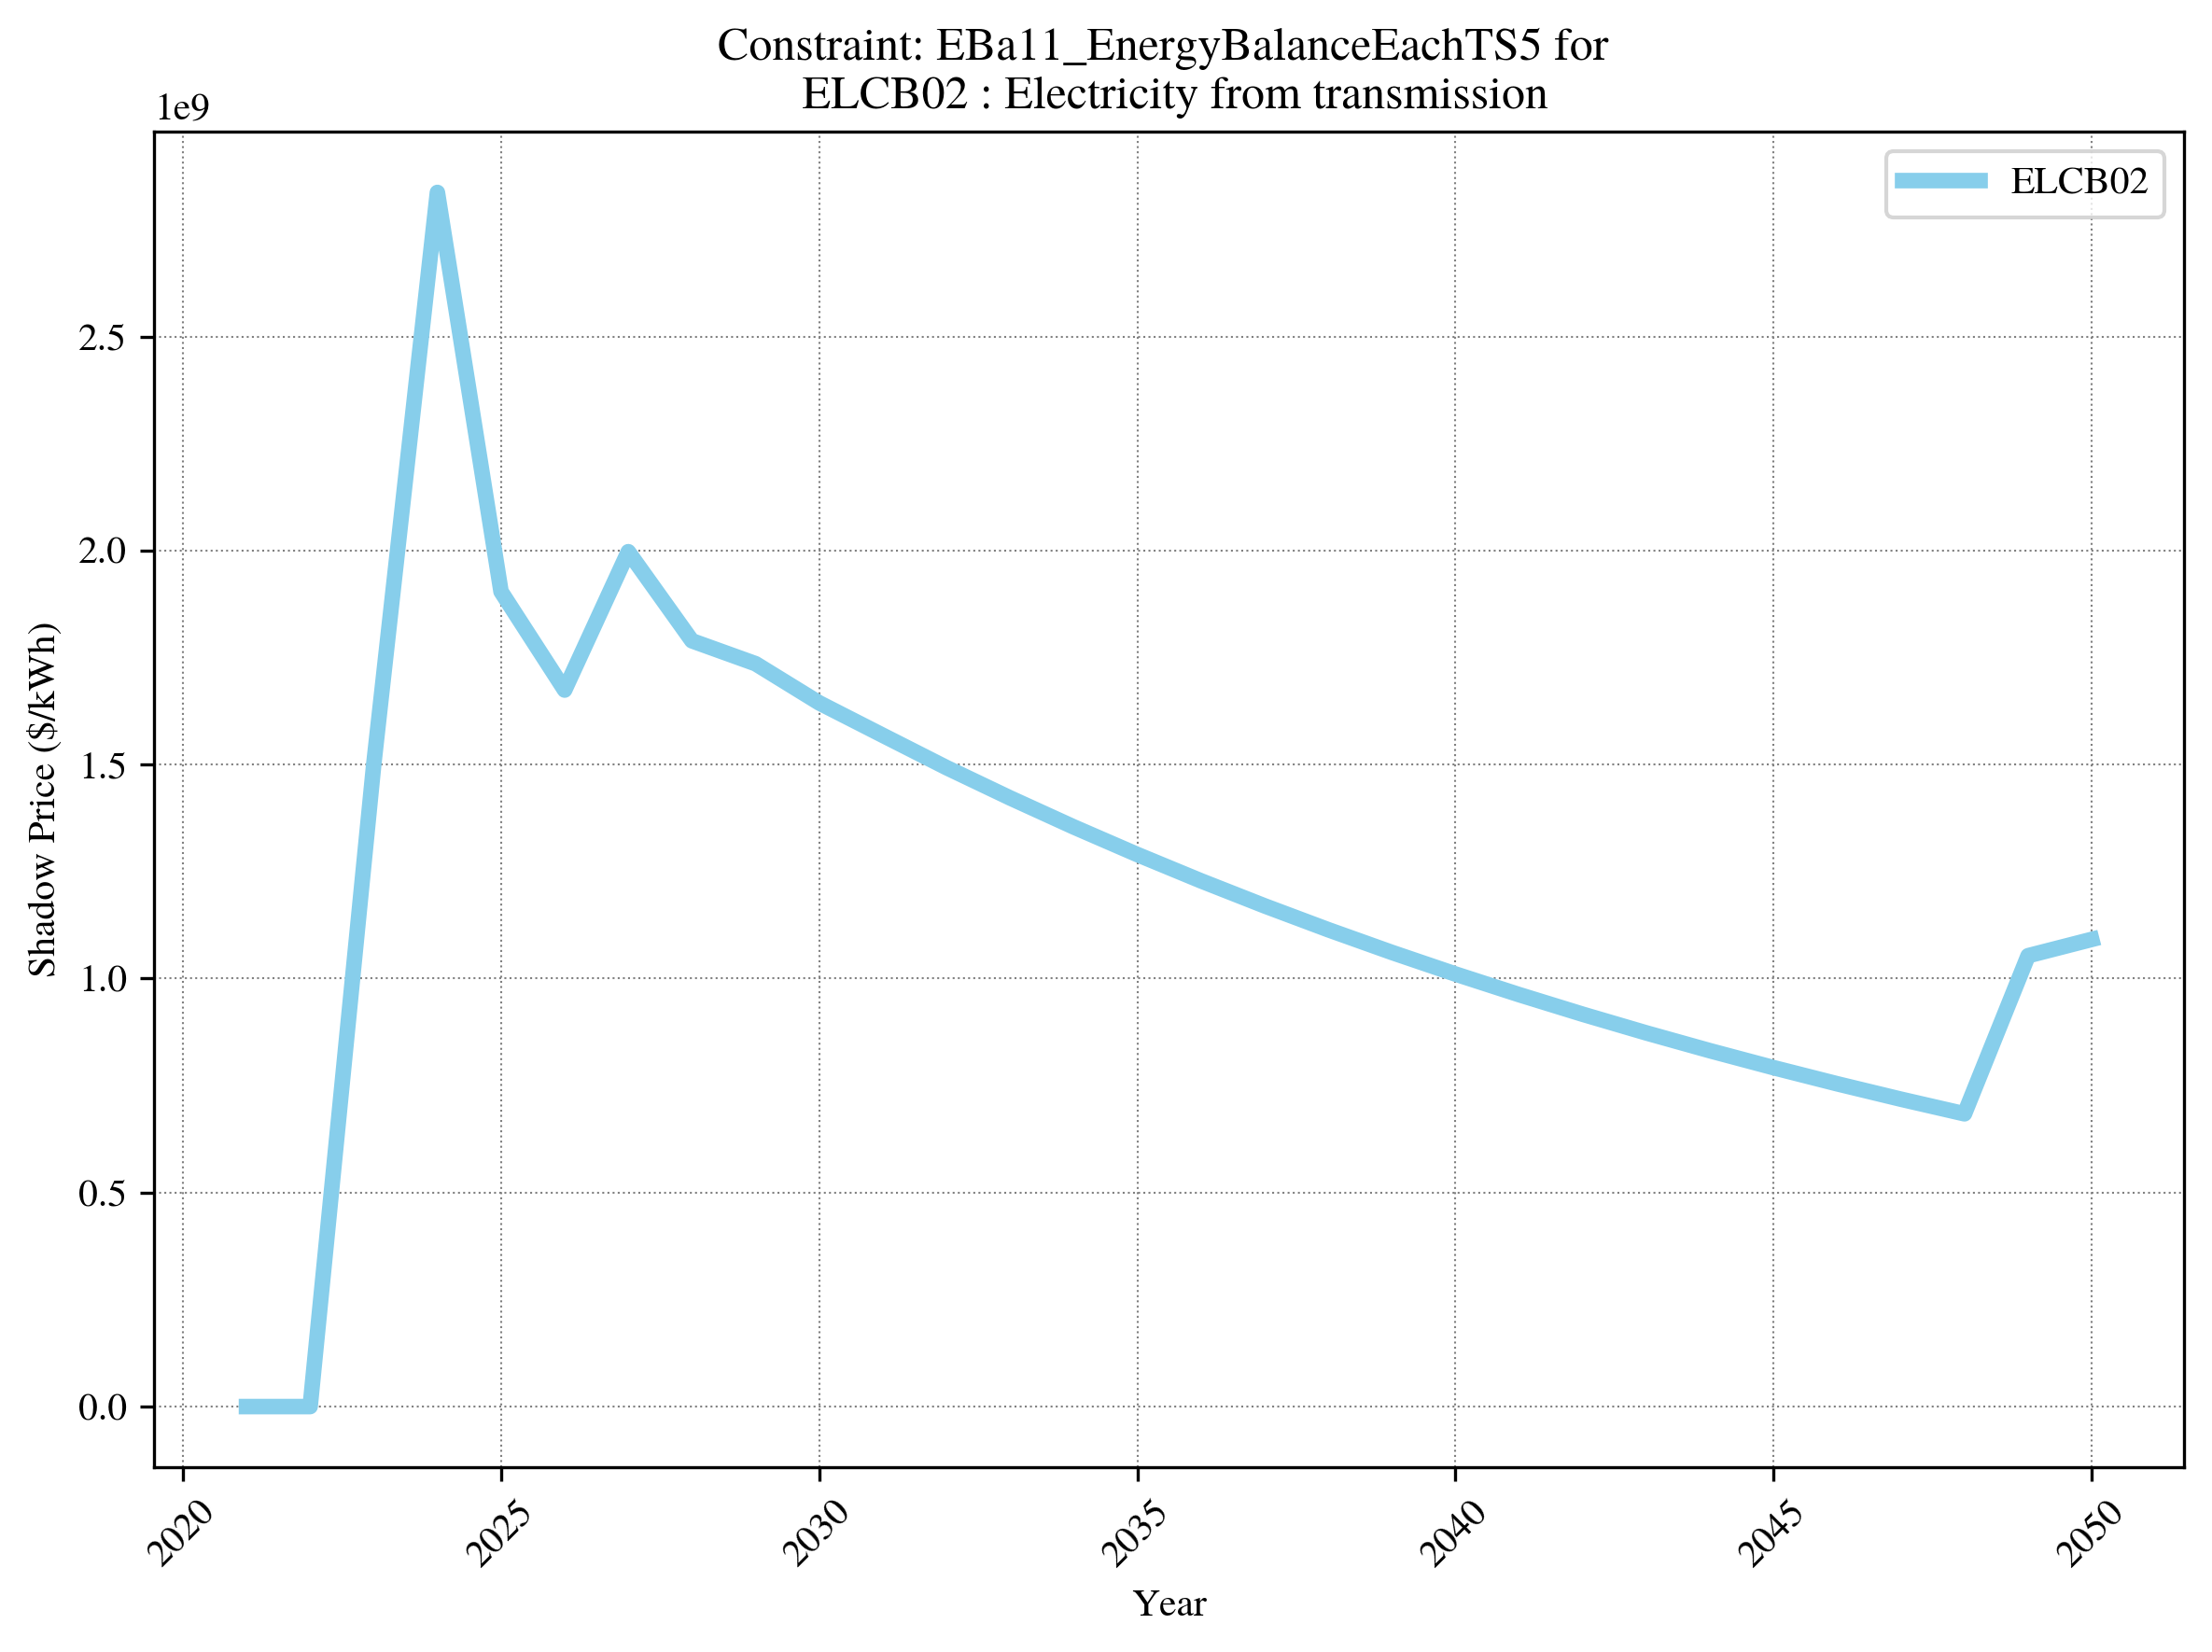

In [4]:
clewsRun = RunModel(**args)
clewsRun.run(update_temporal_profiles=True,
             build=False,
             include_livestock=False,
             threads=32) # The thread depends on the hardware limitations of your machine. If you have 4 core CPU, use Thread <=4 )

---

## 1B : Load the instance of `RunModel` object
<span style="color: yellow;"> - Section 2 is to be used for Debugging and feature Developments</span> 

<span style="color: orange;">   - The sequential steps are included in Clews' Runner Object's method.</span> 

# <span style="color: magenta;"> 2. Model Builder</span> 

 ## <span style="color: magenta;"> _*---------------------------------------------------------------*_
 </span> 

### 2A: Create an instance of the `BuildModel` Object, here named as `clewsBuild`

In [ ]:
from bcnexus.clews.builder import BuildModel
clewsBuild=BuildModel(**args)

### 2B : Build SETs from Model Structure 
> formerly handled by clewsy tool

In [ ]:
# clewsBuild.build_SETs_and_ratios()

- Copy the build SETs to `clews_build_data` directory.

In [ ]:
# utils.copy_csv_files(src_folder=clewsBuild.SETs_save_to, dest_folder=clewsBuild.clews_build_input_csv_dir, all_files=True)

### 2C : Update the Clews Builder Config to handle technology attributes, inclusion of new resource options and technology aggregations.
> Handles `STORAGE` types, `STORAGE_TECHNOLOGY` and non storage technologies named as `TECHNOLOGIES` 

In [ ]:
clewsBuild.update_clews_builder_config()

In [ ]:
clewsBuild.update_temporal_profiles()
# clewsBuild.update_storage_case_SETs()

<span style="color: Yellow;"> 
 >> Now we have to update the associated SETs and Parameters to reflect the changes intended in clews_builder config
</span>

### 2D : Update SETs and Parameters

In [ ]:
clewsBuild.update_set_TECHNOLOGY()

In [ ]:
clewsBuild.update_set_STORAGE()

In [ ]:
clewsBuild.update_yearly_params() 

In [ ]:
clewsBuild.trim_snapshot_data()

In [ ]:
clewsBuild.update_temporal_profiles()

In [ ]:
clewsBuild.update_otoole_config()

In [ ]:
utils.copy_csv_files(src_folder=clewsBuild.clews_build_input_csv_dir,
                    dest_folder=clewsBuild.storage_case_input_csvs,
                    all_files=True)
# clewsBuild.update_storage_case_SETs()

 ## <span style="color: magenta;"> _*---------------------------------------------------------------*_
 </span> 

#  <span style="color: Yellow;">  3. Run Model </span> 

- `build=True` argument handles the workflow run mentioned in __Section 2__
- `update_temporal_profiles=True` collects profiling data 
  - from __'data/clews_data/clews_build_data/inputs_csv_8760'__ 
    - to __'data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs'__

In [ ]:
clewsBuild.update_storage_case_SETs()

In [ ]:
clewsRun.process_scenario_data()

In [ ]:
data_path,model_path=clewsRun.get_model_run_files()

In [ ]:
clewsRun.write_LP_file(model_path,
                       data_path,
                       clewsRun.LP_file
                       )


In [ ]:
clewsRun.solve_model_gurobi(clewsRun.LP_file,
                            "log.txt")

In [ ]:
# clewsRun.run(update_temporal_profiles=False,
#              build=False,
#              include_livestock=False,
#              threads=32) # The thread depends on the hardware limitations of your machine. If you have 4 core CPU, use Thread <=4 )

## Load the Gurobi Model object

In [ ]:
# m=clewsRun.solved_model

In [ ]:
# m.printStats()          # Print basic stats: number of vars, constraints, etc.

In [ ]:
# m.getAttr('Obj')        # Get objective coefficients

In [ ]:
# m.getConstrs()          # List of all constraint objects

# <span style="color: yellow;"> 4 Check Results @ `results\clews\` </span>

In [ ]:
clewsRun.get_result_csvs(debug_mode=True)

# <span style="color: yellow;"> 5. Plot </span>

In [ ]:
import bcnexus.plots as plotter

In [ ]:
plotter.main(args['scenario'],args['storage_algorithm'],timeslices=24)